ROMA / HALLMARK

In [3]:
import pandas as pd
df = pd.read_csv("../data/processed/gsea_cleaned.csv")

In [4]:
# LOADING IN HALLMARK SETS

import json
from pathlib import Path

hallmark_folder = Path('../data/hallmark')

hm_dict = {}

for file in hallmark_folder.iterdir():
    if file.is_file():
      with open(file, 'r') as f:
        data = json.load(f)
      nested = list(data.values())[0]
      hm_dict[nested["systematicName"]] = nested["geneSymbols"]

for key, value in hm_dict.items():
  print(key, " = ", value)

M5901  =  ['ABL1', 'AMD1', 'ARID4A', 'ATF5', 'ATRX', 'AURKA', 'AURKB', 'BARD1', 'BCL3', 'BIRC5', 'BRCA2', 'BUB1', 'BUB3', 'CASP8AP2', 'CBX1', 'CCNA2', 'CCNB2', 'CCND1', 'CCNF', 'CCNT1', 'CDC20', 'CDC25A', 'CDC25B', 'CDC27', 'CDC45', 'CDC6', 'CDC7', 'CDK1', 'CDK4', 'CDKN1B', 'CDKN2C', 'CDKN3', 'CENPA', 'CENPE', 'CENPF', 'CHAF1A', 'CHEK1', 'CHMP1A', 'CKS1B', 'CKS2', 'CTCF', 'CUL1', 'CUL3', 'CUL4A', 'CUL5', 'DBF4', 'DDX39A', 'DKC1', 'DMD', 'DR1', 'DTYMK', 'E2F1', 'E2F2', 'E2F3', 'E2F4', 'EFNA5', 'EGF', 'ESPL1', 'EWSR1', 'EXO1', 'EZH2', 'FANCC', 'FBXO5', 'FOXN3', 'G3BP1', 'GINS2', 'GSPT1', 'H2AX', 'H2AZ1', 'H2AZ2', 'H2BC12', 'HIF1A', 'HIRA', 'HMGA1', 'HMGB3', 'HMGN2', 'HMMR', 'HNRNPD', 'HNRNPU', 'HOXC10', 'HSPA8', 'HUS1', 'ILF3', 'INCENP', 'JPT1', 'KATNA1', 'KIF11', 'KIF15', 'KIF20B', 'KIF22', 'KIF23', 'KIF2C', 'KIF4A', 'KIF5B', 'KMT5A', 'KNL1', 'KPNA2', 'KPNB1', 'LBR', 'LIG3', 'LMNB1', 'MAD2L1', 'MAP3K20', 'MAPK14', 'MARCKS', 'MCM2', 'MCM3', 'MCM5', 'MCM6', 'MEIS1', 'MEIS2', 'MKI67', 'MNA

In [5]:
print(len(hm_dict))

50


In [6]:
# ROMA

from sklearn.decomposition import PCA

pc1_df = pd.DataFrame(index=df.index)

for group, cols in hm_dict.items():
    valid = [col for col in cols if col in df.columns]

    if len(valid) >= 2:
        pca = PCA(n_components=1)
        pc1_values = pca.fit_transform(df[valid])
        pc1_df[group] = pc1_values.flatten()

    elif len(valid) == 1:
        pc1_df[group] = df[pc1_df[0]]
    else:
        print(f"skipping group '{group}', no valid columns found.")

pc1_df["Samples"] = df["Samples"]
pc1_df["C_STAGE"] = df["C_STAGE"]
pc1_df.head()

,M5901,M5911,M5896,M5908,M5956,M5953,M5928,M5893,M5926,M5891,...,M5915,M5932,M5909,M5910,M5930,M5906,M5922,M5942,Samples,C_STAGE
0,1.231851,0.727194,0.587262,0.871050,1.259536,1.321883,0.502901,1.373071,1.103885,1.286626,...,1.397963,1.268630,1.356223,0.982677,1.364673,1.222483,1.082857,1.103885,TCGA-05-4249-01,1
1,-1.281125,-0.756281,-0.610752,-0.905892,-1.309918,-1.374758,-0.523017,-1.427994,-1.148041,-1.338091,...,-1.453881,-1.319376,-1.410472,-1.021984,-1.419260,-1.271382,-1.126171,-1.148041,TCGA-05-4382-01,1
2,5.001314,2.952406,2.384283,3.536463,5.113717,5.366843,2.041778,5.574668,4.481775,5.223702,...,5.675728,5.150639,5.506265,3.989668,5.540572,4.963280,4.396400,4.481775,TCGA-05-4384-01,3
3,-1.281125,-0.756281,-0.610752,-0.905892,-1.309918,-1.374758,-0.523017,-1.427994,-1.148041,-1.338091,...,-1.453881,-1.319376,-1.410472,-1.021984,-1.419260,-1.271382,-1.126171,-1.148041,TCGA-05-4389-01,1
4,5.001314,2.952406,2.384283,3.536463,5.113717,5.366843,2.041778,5.574668,4.481775,5.223702,...,5.675728,5.150639,5.506265,3.989668,5.540572,4.963280,4.396400,4.481775,TCGA-05-4390-01,1


In [7]:
pc1_df.to_csv("../data/results/gsea_luad_pca1_results.csv")

In [8]:
from scipy.stats import f_oneway
import numpy as np

anova_results = []
df = pc1_df.drop("Samples", axis=1)
for col in df.columns.drop("C_STAGE"):
    groups = [df[df["C_STAGE"] == stage][col] for stage in sorted(df["C_STAGE"].unique())]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append((col, f_stat, p_val))

anova_df = pd.DataFrame(anova_results, columns=["Module", "F_stat", "p_value"])
anova_df["neg_log10_p"] = -np.log10(anova_df["p_value"])
anova_df.sort_values("p_value", inplace=True)

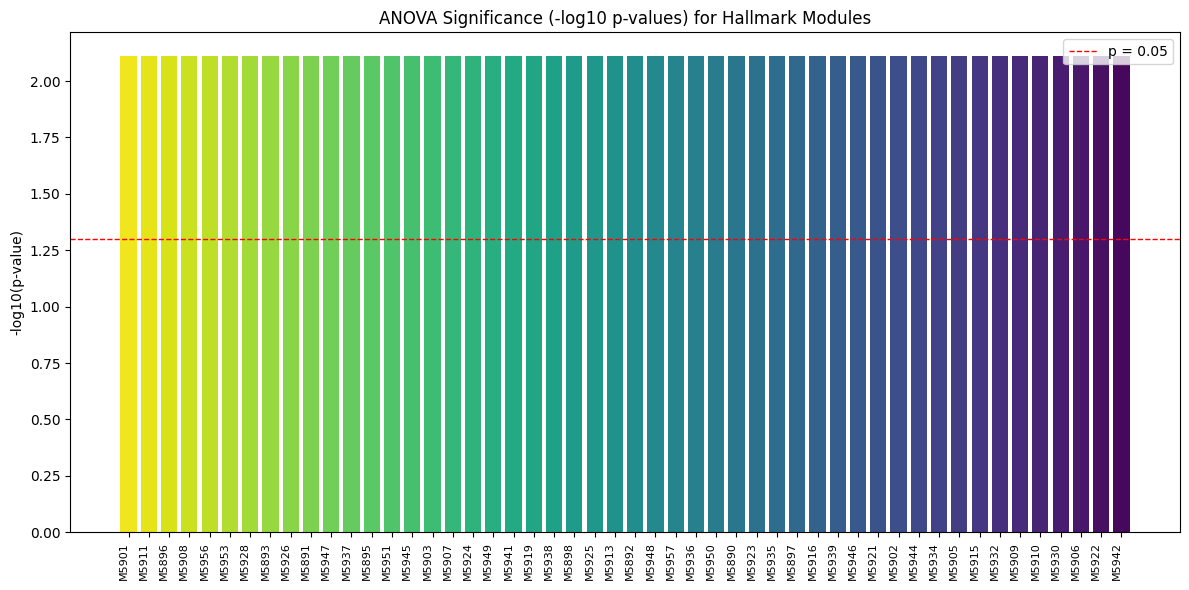

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
colors = sns.color_palette("viridis_r", len(anova_df))

plt.bar(anova_df["Module"], anova_df["neg_log10_p"], color=colors)
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.ylabel("-log10(p-value)")
plt.title("ANOVA Significance (-log10 p-values) for Hallmark Modules")
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p = 0.05')

plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_19040/3770643211.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x="Spearman_corr", y="Module", palette="viridis")


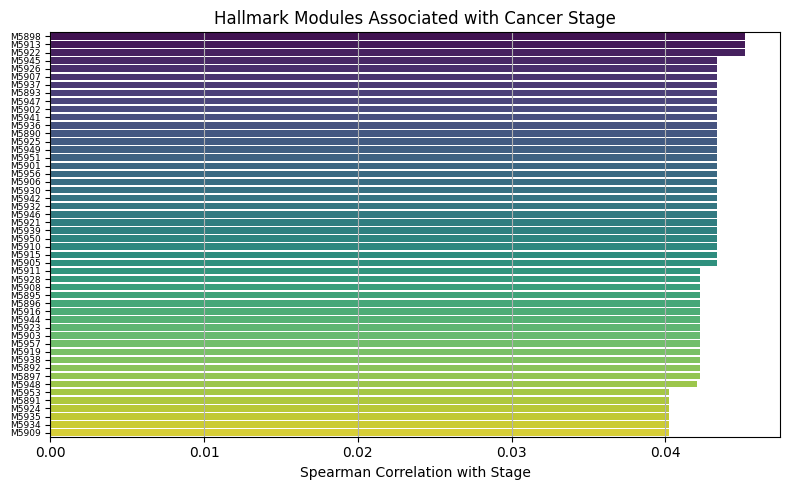

In [10]:
from scipy.stats import spearmanr

corr_results = []
df = pc1_df.drop("Samples", axis=1)
for col in df.columns.drop(["C_STAGE"]):
    corr, p_val = spearmanr(df[col], df["C_STAGE"])
    corr_results.append((col, corr, p_val))

corr_df = pd.DataFrame(corr_results, columns=["Module", "Spearman_corr", "p_value"])
corr_df["neg_log10_p"] = -np.log10(corr_df["p_value"])
corr_df.sort_values("Spearman_corr", ascending=False, inplace=True)

plt.figure(figsize=(8,5))
plt.yticks(fontsize=6.5)
plt.grid()
sns.barplot(data=corr_df, x="Spearman_corr", y="Module", palette="viridis")
plt.title("Hallmark Modules Associated with Cancer Stage")
plt.xlabel("Spearman Correlation with Stage")
plt.ylabel("")
plt.tight_layout()
plt.show()